## 1. Homology-Aware Data Splitting

**Goal:** before doing any train/test split, check whether the dataset contains near-duplicate or highly similar peptide sequences. If it does, a naive random split could place near-identical peptides on both sides of the split, letting information leak from train into test and inflating reported performance.

**Tool:** [CD-HIT](http://weizhong-lab.ucsd.edu/cd-hit/) clusters sequences by pairwise similarity, greedily grouping anything above a chosen identity threshold (`-c`) into the same cluster. The word length (`-n`) must be matched to `-c` per CD-HIT's own guidance (shorter words for looser thresholds). If sequences cluster heavily, a *cluster-aware* split (keeping every member of a cluster on the same side) is needed instead of a plain random split.

The next two cells mount Google Drive (where the dataset lives) and install CD-HIT on the Colab runtime.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
folder_dir = r'/content/drive/MyDrive/IIMT/'

In [ ]:
!sudo apt-get install -y cd-hit

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cd-hit is already the newest version (4.8.1-4).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.


Running CD-HIT at three identity thresholds, from strict to lenient, to see at what point (if any) sequences start clustering together:

| Threshold (`-c`) | Word length (`-n`) | Interpretation |
|---|---|---|
| 0.90 | 5 | Only near-identical sequences (≥90% identity) cluster |
| 0.70 | 4 | Moderately similar sequences cluster |
| 0.40 | 2 | Very loose — CD-HIT's practical floor for meaningful clustering |

If even the loosest threshold (0.40) fails to merge sequences, that's strong evidence the dataset is genuinely diverse rather than the threshold being mis-tuned.

In [ ]:
!cd-hit -i /content/drive/MyDrive/IIMT/sequences.fasta -o /content/drive/MyDrive/IIMT/output/out_90.fasta -c 0.9 -n 5 -d 0

Program: CD-HIT, V4.8.1 (+OpenMP), Aug 20 2021, 08:39:56
Command: cd-hit -i /content/drive/MyDrive/IIMT/sequences.fasta
         -o /content/drive/MyDrive/IIMT/output/out_90.fasta -c
         0.9 -n 5 -d 0

Started: Sat Jul 25 16:03:25 2026
                            Output                              
----------------------------------------------------------------
total seq: 156
longest and shortest : 99 and 25
Total letters: 11207
Sequences have been sorted

Approximated minimal memory consumption:
Sequence        : 0M
Buffer          : 1 X 10M = 10M
Table           : 1 X 65M = 65M
Miscellaneous   : 0M
Total           : 75M

Table limit with the given memory limit:
Max number of representatives: 4000000
Max number of word counting entries: 90513425

comparing sequences from          0  to        156

      156  finished        156  clusters

Approximated maximum memory consumption: 75M
writing new database
writing clustering information
program completed !

Total CPU time 0.08


In [ ]:
!cd-hit -i /content/drive/MyDrive/IIMT/sequences.fasta -o /content/drive/MyDrive/IIMT/output/out_70.fasta -c 0.7 -n 4 -d 0

Program: CD-HIT, V4.8.1 (+OpenMP), Aug 20 2021, 08:39:56
Command: cd-hit -i /content/drive/MyDrive/IIMT/sequences.fasta
         -o /content/drive/MyDrive/IIMT/output/out_70.fasta -c
         0.7 -n 4 -d 0

Started: Sat Jul 25 16:03:25 2026
                            Output                              
----------------------------------------------------------------
Your word length is 4, using 5 may be faster!
total seq: 156
longest and shortest : 99 and 25
Total letters: 11207
Sequences have been sorted

Approximated minimal memory consumption:
Sequence        : 0M
Buffer          : 1 X 10M = 10M
Table           : 1 X 3M = 3M
Miscellaneous   : 0M
Total           : 13M

Table limit with the given memory limit:
Max number of representatives: 4000000
Max number of word counting entries: 98292665

comparing sequences from          0  to        156

      156  finished        156  clusters

Approximated maximum memory consumption: 13M
writing new database
writing clustering information


In [ ]:
!cd-hit -i /content/drive/MyDrive/IIMT/sequences.fasta -o /content/drive/MyDrive/IIMT/output/out_40.fasta -c 0.4 -n 2 -d 0

Program: CD-HIT, V4.8.1 (+OpenMP), Aug 20 2021, 08:39:56
Command: cd-hit -i /content/drive/MyDrive/IIMT/sequences.fasta
         -o /content/drive/MyDrive/IIMT/output/out_40.fasta -c
         0.4 -n 2 -d 0

Started: Sat Jul 25 16:03:25 2026
                            Output                              
----------------------------------------------------------------
total seq: 156
longest and shortest : 99 and 25
Total letters: 11207
Sequences have been sorted

Approximated minimal memory consumption:
Sequence        : 0M
Buffer          : 1 X 10M = 10M
Table           : 1 X 0M = 0M
Miscellaneous   : 0M
Total           : 10M

Table limit with the given memory limit:
Max number of representatives: 4000000
Max number of word counting entries: 98680745

comparing sequences from          0  to        156

      156  finished        148  clusters

Approximated maximum memory consumption: 10M
writing new database
writing clustering information
program completed !

Total CPU time 0.12


**Finding:** all three runs — at 90%, 70%, and even the very lenient 40% identity threshold — returned **156 clusters for 156 sequences**. Every peptide ended up in its own singleton cluster, meaning no two sequences in this dataset are similar enough to be considered redundant, even by a generous definition of "similar."

This is plausible for a curated AMP dataset, since such datasets are typically assembled from many different peptide families (defensins, cathelicidins, cecropins, etc.) that share antimicrobial function without sharing much sequence identity.

**Decision:** since there's no detectable homology-driven redundancy, a straightforward **stratified random train/test split** (stratified on `Class`) is sufficient — there's no cluster structure to preserve, so cluster-aware grouping would add complexity without changing anything.

## 2. Peptide Embeddings via ProtBERT

Generating a fixed-length numerical representation for every peptide sequence using [ProtBERT](https://huggingface.co/Rostlab/prot_bert) (`Rostlab/prot_bert`), a BERT model pretrained on protein sequences, so these embeddings can later be combined with curated biophysical features for classification.

**Pipeline in this section:**
1. Install a pinned `transformers` version (`4.46.0`) — newer versions have a known tokenizer-loading bug with this specific model repo (see below).
2. Check for GPU availability — this run detected a **Tesla T4**, so embedding generation runs on GPU rather than CPU.
3. Load the ProtBERT tokenizer (`use_fast=False`, `do_lower_case=False`) and model. `use_fast=False` sidesteps a bug where `AutoTokenizer`'s auto-conversion path misidentifies this model's WordPiece tokenizer as a SentencePiece one and fails looking for a package it doesn't actually need.
4. Preprocess each sequence: uppercase it, map rare/ambiguous residues (`U`, `Z`, `O`, `B`) to `X` (not in ProtBERT's vocabulary), and space out the amino acids (`"MSQ..."` → `"M S Q ..."`), since that's the tokenization format ProtBERT was trained on.
5. Run the model and **mean-pool** the per-residue hidden states into a single fixed-length vector per sequence — excluding `[CLS]`, `[SEP]`, and `[PAD]` positions from the average (masked out by token ID, not by position, so it's robust regardless of padding).
6. Sanity-check on one sequence first (`test_sequence`) — confirms a single peptide produces a **1024-dimensional** embedding vector, matching ProtBERT's hidden size.
7. Load the full combined AMP/NAMP dataset and embed all sequences in batches (`embed_peptides`), producing an `(N, 1024)` embedding matrix.
8. Attach the embeddings as `embedding_0` ... `embedding_1023` columns alongside the original data and save the combined table to `peptide-embeddings.csv` for the next steps.

In [ ]:
!pip install -q "transformers==4.46.0" torch accelerate sentencepiece tiktoken

In [ ]:
import re
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel

# Check hardware availability
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ GPU detected: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("⚠️ No GPU detected. Execution will be very slow. Check Runtime > Change runtime type.")

✅ GPU detected: Tesla T4


In [ ]:
def load_protbert(device):
    model_name = "Rostlab/prot_bert"
    print(f"Downloading/Loading {model_name}...")

    # do_lower_case=False is required for ProtBERT (it only understands uppercase)
    tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=False, use_fast=False)
    model = AutoModel.from_pretrained(model_name)

    # Move model to GPU and set to evaluation mode
    model = model.to(device)
    model.eval()

    print("Model loaded successfully!")
    return model, tokenizer

model, tokenizer = load_protbert(device)

Downloading/Loading Rostlab/prot_bert...
Model loaded successfully!


In [ ]:
def _preprocess_sequence(sequence):
    """
    ProtBERT expects amino acids space-separated, and rare/ambiguous
    residues (U, Z, O, B) mapped to X since they aren't in its vocab [1].
    """
    sequence = sequence.upper()
    sequence = re.sub(r"[UZOB]", "X", sequence)
    return " ".join(list(sequence))

@torch.inference_mode() # Disables gradient calculations to save memory and speed up inference
def _embed_token_batch(sequences, model, tokenizer, device):
    """Tokenize, pad, and embed one batch with mask-aware mean pooling."""
    spaced_sequences = [_preprocess_sequence(seq) for seq in sequences]

    inputs = tokenizer(
        spaced_sequences,
        padding=True,
        return_tensors="pt",
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    outputs = model(**inputs)
    emb = outputs.last_hidden_state  # Shape: (batch, seq_len, hidden_dim)

    # Exclude [PAD], [CLS], and [SEP] positions from the pooling average.
    pool_mask = inputs["attention_mask"].clone()
    pool_mask[inputs["input_ids"] == tokenizer.cls_token_id] = 0
    pool_mask[inputs["input_ids"] == tokenizer.sep_token_id] = 0

    pool_mask = pool_mask.unsqueeze(-1).float()       # (batch, seq_len, 1)
    summed = (emb * pool_mask).sum(dim=1)             # (batch, hidden_dim)
    counts = pool_mask.sum(dim=1).clamp(min=1)        # avoid divide-by-zero
    emb_avg = summed / counts

    return emb_avg.cpu()

def embed_peptides(sequences, model, tokenizer, device, batch_size=16, sort_by_length=True):
    """
    Convert a list of N peptide sequences to an (N, embed_dim) embedding matrix.
    """
    order = list(range(len(sequences)))

    # Grouping similar length sequences saves massive amounts of padding memory
    if sort_by_length:
        order.sort(key=lambda i: len(sequences[i]))
    sorted_seqs = [sequences[i] for i in order]

    all_embeddings = []

    print(f"Embedding {len(sequences)} sequences in batches of {batch_size}...")
    for start in range(0, len(sorted_seqs), batch_size):
        batch = sorted_seqs[start:start + batch_size]
        all_embeddings.append(_embed_token_batch(batch, model, tokenizer, device))

    embeddings_sorted = torch.cat(all_embeddings, dim=0)

    # Restore original sequence order
    inverse_order = np.argsort(order)
    embeddings = embeddings_sorted[inverse_order]
    return embeddings.numpy()

def embed_peptide(sequence, model, tokenizer, device):
    """
    Convert a single peptide sequence to its embedding vector.

    Returns
    -------
    np.ndarray of shape (embed_dim,)
    """
    return embed_peptides([sequence], model, tokenizer, device, batch_size=1)[0]

In [ ]:
test_sequence = "MSQNVLTVYGADWCRDCLRTKRQLDELGVAYDYVDLVADPAQADAAERISGRKNIPVVVFPDGDHQVEPTNEETAAKLTALGLI"

embedding = embed_peptide(test_sequence, model, tokenizer, device)

Embedding 1 sequences in batches of 1...


In [ ]:
embedding

array([-0.008985  ,  0.0173782 , -0.00283964, ...,  0.00351976,
       -0.00814824, -0.01149773], dtype=float32)

In [ ]:
embedding.shape

(1024,)

In [ ]:
import pandas as pd

combined_amp_df = pd.read_csv(r'/content/drive/MyDrive/IIMT/amp-combined-dataset.csv')
combined_amp_df

,Sequence,Class
0,MSQNVLTVYGADWCRDCLRTKRQLDELGVAYDYVDLVADPAQADAA...,AMP
1,MAKAELRKPKPKSNPLKAAKITEIDYKDVALLRKFISDRGKIRARR...,AMP
2,MAEKKTEKNGAPMGPGTSSIKDPEVYEALRREGASEEKAARIANAS...,AMP
3,VNFALDGRNYEIDLSKEHAAELREFLKPYMKKGRAVAPPSPKVEAA...,AMP
4,MTDVPFEDREDERELETDLLADPNAAGDPEPEDGRDGQPVRGGSDD...,AMP
...,...,...
151,MPEQCPPSVSDQDQIPTLTDQQWTEFVSDAHAMRQAETTLEAGMAD...,NAMP
152,MEFDPETNTYSSNGPTTRLRNAEQENRDLKRRLKDLEDRVDRLEEI...,NAMP
153,MPVSPCPECGRPVIPAGIGQPPRFCSTSCRQRRHRKVKNVRQQLAE...,NAMP
154,VKTRRAYTAAGMAAFLSELQRRHGAPAQTGTRVGVHPAPQETPPLT...,NAMP


In [ ]:
amp_sequences = combined_amp_df['Sequence'].values.tolist()

peptide_embeddings = embed_peptides(amp_sequences, model, tokenizer, device)

Embedding 156 sequences in batches of 16...


In [ ]:
embedding_colnames = [f'embedding_{i}' for i in range(peptide_embeddings.shape[1])]

embedding_df = pd.DataFrame(peptide_embeddings, columns=embedding_colnames)
embedding_df

,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,...,embedding_1014,embedding_1015,embedding_1016,embedding_1017,embedding_1018,embedding_1019,embedding_1020,embedding_1021,embedding_1022,embedding_1023
0,-0.008985,0.017378,-0.002840,-0.009631,-0.021429,-0.011779,0.002319,0.024584,0.007426,0.028633,...,0.009096,0.036054,0.056407,0.052993,-0.041445,-0.044127,-0.047257,0.003520,-0.008148,-0.011498
1,0.048892,0.084799,-0.005117,-0.063326,0.027530,-0.018484,-0.007901,-0.043478,0.004957,0.018498,...,0.014493,0.022756,0.098569,0.015457,0.007456,-0.054916,-0.066401,-0.075455,-0.005419,-0.002940
2,0.011814,-0.039252,-0.010505,-0.009206,-0.103195,-0.018718,-0.019546,-0.013124,-0.028815,0.019720,...,-0.018050,0.033157,0.065440,-0.010878,-0.038303,-0.000169,-0.036347,-0.060823,-0.025264,-0.013863
3,0.001706,-0.026421,-0.002855,0.032163,-0.017155,-0.030749,-0.019276,-0.040381,-0.024304,0.041230,...,0.020269,0.001615,0.035109,0.002537,0.004588,-0.020035,-0.043304,-0.015673,-0.000451,0.001353
4,0.053323,-0.023446,0.032147,-0.080743,-0.024467,0.046960,0.009368,0.024712,-0.016717,0.029250,...,-0.018460,0.028109,-0.049307,-0.024608,-0.012626,-0.032832,0.042288,-0.007861,-0.038923,0.016073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,-0.025942,0.019734,0.030548,0.001928,0.003905,0.042358,0.008817,0.010928,0.006088,0.006195,...,0.034437,0.024037,-0.034300,-0.020605,-0.003305,-0.027899,0.001619,0.006602,-0.009404,0.025001
152,0.014857,-0.020122,0.028800,-0.005652,-0.086044,0.039791,-0.011187,0.000632,0.002489,-0.025856,...,-0.000990,-0.006877,-0.035178,0.035528,-0.054051,0.021152,0.013864,-0.021913,-0.017699,0.034205
153,0.015512,0.028482,0.005047,0.005234,-0.002282,0.026415,-0.015536,0.025225,-0.044981,-0.007399,...,0.000479,0.004642,-0.016215,-0.019438,0.027508,-0.023895,-0.015573,0.034197,-0.040272,0.021837
154,0.047367,0.009725,0.026069,-0.066542,0.004086,0.035616,-0.014974,0.035155,-0.041189,-0.024832,...,0.015638,0.014011,-0.028309,-0.024910,0.031057,-0.027550,-0.019984,-0.001811,-0.020987,0.044513


In [ ]:
combined_embedding_df = pd.concat([combined_amp_df, embedding_df], axis=1)
combined_embedding_df

,Sequence,Class,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,...,embedding_1014,embedding_1015,embedding_1016,embedding_1017,embedding_1018,embedding_1019,embedding_1020,embedding_1021,embedding_1022,embedding_1023
0,MSQNVLTVYGADWCRDCLRTKRQLDELGVAYDYVDLVADPAQADAA...,AMP,-0.008985,0.017378,-0.002840,-0.009631,-0.021429,-0.011779,0.002319,0.024584,...,0.009096,0.036054,0.056407,0.052993,-0.041445,-0.044127,-0.047257,0.003520,-0.008148,-0.011498
1,MAKAELRKPKPKSNPLKAAKITEIDYKDVALLRKFISDRGKIRARR...,AMP,0.048892,0.084799,-0.005117,-0.063326,0.027530,-0.018484,-0.007901,-0.043478,...,0.014493,0.022756,0.098569,0.015457,0.007456,-0.054916,-0.066401,-0.075455,-0.005419,-0.002940
2,MAEKKTEKNGAPMGPGTSSIKDPEVYEALRREGASEEKAARIANAS...,AMP,0.011814,-0.039252,-0.010505,-0.009206,-0.103195,-0.018718,-0.019546,-0.013124,...,-0.018050,0.033157,0.065440,-0.010878,-0.038303,-0.000169,-0.036347,-0.060823,-0.025264,-0.013863
3,VNFALDGRNYEIDLSKEHAAELREFLKPYMKKGRAVAPPSPKVEAA...,AMP,0.001706,-0.026421,-0.002855,0.032163,-0.017155,-0.030749,-0.019276,-0.040381,...,0.020269,0.001615,0.035109,0.002537,0.004588,-0.020035,-0.043304,-0.015673,-0.000451,0.001353
4,MTDVPFEDREDERELETDLLADPNAAGDPEPEDGRDGQPVRGGSDD...,AMP,0.053323,-0.023446,0.032147,-0.080743,-0.024467,0.046960,0.009368,0.024712,...,-0.018460,0.028109,-0.049307,-0.024608,-0.012626,-0.032832,0.042288,-0.007861,-0.038923,0.016073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,MPEQCPPSVSDQDQIPTLTDQQWTEFVSDAHAMRQAETTLEAGMAD...,NAMP,-0.025942,0.019734,0.030548,0.001928,0.003905,0.042358,0.008817,0.010928,...,0.034437,0.024037,-0.034300,-0.020605,-0.003305,-0.027899,0.001619,0.006602,-0.009404,0.025001
152,MEFDPETNTYSSNGPTTRLRNAEQENRDLKRRLKDLEDRVDRLEEI...,NAMP,0.014857,-0.020122,0.028800,-0.005652,-0.086044,0.039791,-0.011187,0.000632,...,-0.000990,-0.006877,-0.035178,0.035528,-0.054051,0.021152,0.013864,-0.021913,-0.017699,0.034205
153,MPVSPCPECGRPVIPAGIGQPPRFCSTSCRQRRHRKVKNVRQQLAE...,NAMP,0.015512,0.028482,0.005047,0.005234,-0.002282,0.026415,-0.015536,0.025225,...,0.000479,0.004642,-0.016215,-0.019438,0.027508,-0.023895,-0.015573,0.034197,-0.040272,0.021837
154,VKTRRAYTAAGMAAFLSELQRRHGAPAQTGTRVGVHPAPQETPPLT...,NAMP,0.047367,0.009725,0.026069,-0.066542,0.004086,0.035616,-0.014974,0.035155,...,0.015638,0.014011,-0.028309,-0.024910,0.031057,-0.027550,-0.019984,-0.001811,-0.020987,0.044513


In [ ]:
combined_embedding_df.to_csv(r'/content/drive/MyDrive/IIMT/output/peptide-embeddings.csv', index=False)

## 3. Train/Test Split & PCA Dimensionality Reduction

**Train/test split:** the combined dataset (sequences + 1024-dim embeddings) is split 80/20 with `stratify=y` on `Class`, so AMP/NAMP proportions stay consistent across both sets:
- **Train:** 124 rows (61.3% NAMP / 38.7% AMP)
- **Test:** 32 rows (62.5% NAMP / 37.5% AMP)

`random_state=42` is fixed so this split is reproducible across the rest of the pipeline.

**PCA on the embeddings:** 1024 raw ProtBERT dimensions are too many, too correlated, and too individually uninterpretable to feed directly into feature selection alongside a handful of curated biophysical features. To address this:
1. Fit `StandardScaler` + `PCA(n_components=0.95)` **on the training embeddings only** — fitting on train-only avoids leaking any test-set structure into the PCA basis itself.
2. Result: **76 components** are needed to retain ≥95% of the variance in the 1024-dim embedding space (95.16% captured exactly) — a solver setting of `svd_solver='full'` is required whenever `n_components` is given as a variance fraction rather than an integer.
3. The **same fitted `pca_pipeline`** (already fit on train) is then applied to the test set embeddings via `.transform()` only — never refit — which is what keeps this step leakage-free.
4. Reduced embeddings (`reduced_0` ... `reduced_75`) are recombined with `Sequence`/`Class` and saved separately for train (124 × 76) and test (32 × 76) as `train-124-embd-reduced.csv` / `test-32-embd-reduced.csv`.

In [ ]:
from sklearn.model_selection import train_test_split

# test-train split 20-80, keep True-False labels in equal proportion in both test and train set
X = combined_embedding_df.drop(columns=['Class'])
y = combined_embedding_df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,          # 20% allocated to the test set
    random_state=42,        # Ensures identical split across runs
    stratify=y              # Maintains TargetClass proportions
)

print(f"Training set row count: {len(X_train)}")
print(f"Testing set row count: {len(X_test)}")
print("\nTraining class proportions:\n", y_train.value_counts(normalize=True))
print("\nTesting class proportions:\n", y_test.value_counts(normalize=True))

Training set row count: 124
Testing set row count: 32

Training class proportions:
 Class
NAMP    0.612903
AMP     0.387097
Name: proportion, dtype: float64

Testing class proportions:
 Class
NAMP    0.625
AMP     0.375
Name: proportion, dtype: float64


In [ ]:
# Train and test dataframes
train_df = combined_embedding_df.loc[X_train.index]
test_df = combined_embedding_df.loc[X_test.index]
train_df

,Sequence,Class,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,...,embedding_1014,embedding_1015,embedding_1016,embedding_1017,embedding_1018,embedding_1019,embedding_1020,embedding_1021,embedding_1022,embedding_1023
71,MDRELRTPPELEGVDWYDDAPRRPRPIVTLVAWIAILGLVLSVGAG...,NAMP,0.003676,-0.025156,-0.001905,-0.000678,-0.018736,0.042012,-0.024880,0.037399,...,-0.000040,-0.017328,-0.041560,0.017038,-0.017331,-0.048533,-0.007467,-0.012957,-0.019372,0.050202
35,MIMGFIDQMRAKGHAVESICRVLRQEGCQIAARTYRAWRRRSASAR...,AMP,0.043530,0.035095,0.038822,-0.080663,-0.005887,-0.017940,0.015312,-0.020344,...,0.006134,-0.014152,-0.014631,-0.003935,0.020900,-0.044250,-0.049214,0.003422,-0.012044,0.019152
3,VNFALDGRNYEIDLSKEHAAELREFLKPYMKKGRAVAPPSPKVEAA...,AMP,0.001706,-0.026421,-0.002855,0.032163,-0.017155,-0.030749,-0.019276,-0.040381,...,0.020269,0.001615,0.035109,0.002537,0.004588,-0.020035,-0.043304,-0.015673,-0.000451,0.001353
43,MSTRRPAHQPTRGTAAPRGFVSPWEHGSRLYRTLVLTGSALFLVGI...,AMP,0.003046,0.020228,-0.017663,-0.020406,-0.020490,0.056863,-0.036302,0.073308,...,0.021685,0.003307,-0.067470,0.025244,-0.021704,-0.077843,-0.042389,0.004553,-0.048197,0.041312
88,MLHHHAITVLAALRALIHDDVRDERGDVPGWVMITLMSAVLVAGLL...,NAMP,0.007508,0.022801,-0.039674,-0.032713,0.016335,0.016949,-0.002113,0.040249,...,-0.025686,-0.005855,0.051328,0.016485,-0.038261,-0.071960,-0.053300,-0.054792,-0.015791,0.026879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,MDWRSKAACLDKDPELFFPVGNTGPALLQIEEAKAVCRSCEVVDTC...,AMP,0.094097,0.036568,0.004181,-0.049333,0.016626,-0.033175,0.002117,0.013915,...,-0.018823,0.017519,0.092487,-0.013905,-0.021723,-0.021980,-0.036377,-0.059997,-0.032622,-0.012285
32,MGNTLGFLRGVDRLHAFYTENVRMLAHAYDLTDEEASELLANTGFT...,AMP,0.037475,0.010156,0.030232,-0.027071,-0.025749,0.040987,-0.008931,0.009929,...,-0.003147,0.014273,-0.021682,-0.016862,0.012530,-0.018349,0.011020,-0.029485,-0.018962,0.057869
9,MSIVQIDVEDLRAKSGAVEGSIGRLQAEVSTMEANLRQLQDTWRGQ...,AMP,-0.046805,0.040442,-0.035781,-0.026834,0.030514,-0.081054,-0.009207,0.000642,...,0.037967,-0.007793,0.065092,-0.022760,-0.052190,-0.040074,-0.010971,-0.010438,0.001940,-0.005474
21,VKTFDELYAELTRKVQERPEGSGTVAQIDAGVHAIGKKVVEEAAEV...,AMP,0.016931,0.078520,-0.032290,-0.070857,-0.068480,-0.036348,-0.020316,0.005503,...,-0.007696,0.036929,0.114347,0.023297,-0.029347,-0.044003,-0.075176,-0.051938,-0.058392,-0.042123


In [ ]:
test_df

,Sequence,Class,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,...,embedding_1014,embedding_1015,embedding_1016,embedding_1017,embedding_1018,embedding_1019,embedding_1020,embedding_1021,embedding_1022,embedding_1023
7,MSGPTCRHCADWAYGYAEGYAQGHASGLAAGRVQGAAEGPAHPAIA...,AMP,0.045065,-0.018878,0.030171,-0.054786,0.021445,0.035571,-0.005085,0.026688,...,0.052304,-0.025710,-0.044165,-0.003185,0.034120,-0.061074,-0.020430,-0.010550,-0.029159,0.006896
38,MSVSIKPLEDRIVVRPLEAEQTTASGLVIPDTAKEKPQEGQVVAVG...,AMP,0.008378,0.064574,-0.027825,-0.045415,-0.015636,-0.027202,-0.008684,-0.020702,...,-0.017942,-0.011279,0.110678,0.046938,0.007534,-0.018577,-0.063573,-0.030860,-0.007127,-0.013621
143,MSIRYPLGYVENERKVYPQGYARERVSPGGDGEGRHDQETSPGGVS...,NAMP,0.045733,0.048348,0.077874,-0.056787,0.054389,-0.034896,-0.001873,0.017009,...,0.032518,-0.018133,-0.072586,-0.051796,0.048287,-0.001256,-0.039640,0.069252,-0.056023,0.049736
95,MTAQLSSNAPRPRDSSAYVTVHSRGGQKVFVRDAAKRETLRRADAL...,NAMP,0.056978,0.025398,0.052960,-0.059705,-0.000026,0.026409,-0.004477,0.030104,...,0.034478,-0.010459,-0.037320,-0.018896,0.015675,-0.034239,-0.035148,0.019793,0.003341,0.021824
140,MADQQIPETKNSDAPGDQDQAAQQAPAEVDGLAAKAEQSEKETEEN...,NAMP,0.019469,-0.050906,0.033356,-0.052834,0.002651,0.030329,-0.003930,-0.035597,...,-0.006595,0.012712,-0.021353,-0.062452,0.011580,-0.042460,-0.010827,-0.016712,-0.010497,0.038307
59,MYSVYAQHWQRDTEAAASARVYRVSRLRHDAAPAPGVSIFRHGRPV...,AMP,0.060995,0.019966,0.022219,-0.045560,-0.001068,0.048299,-0.026643,0.024940,...,0.001653,0.020183,-0.049815,0.012186,0.017341,-0.069625,-0.025524,-0.009629,-0.029156,0.014577
133,MADLAGISDATVRQIERSTGRGTLSSLLAVLGVLGLDLEARR,NAMP,-0.004256,0.005857,0.017299,-0.017960,-0.045945,0.045401,0.030998,0.013677,...,-0.004804,0.009489,-0.004631,0.061996,0.005009,-0.000708,-0.020363,-0.023085,0.015683,0.003180
146,MTTQQQTVTIPAGFAPEQIPLIEGKSETFISYQGPASGHVST,NAMP,-0.003966,0.000650,0.017948,-0.047592,0.039467,-0.002805,-0.008322,0.032555,...,-0.006915,-0.018241,-0.029692,0.019429,0.007530,-0.047371,-0.000529,0.039377,-0.034336,0.027623
28,MQLLLALAYIALTVVLAALTVRIVLDVTQSFVRHWRPTGAALMLAS...,AMP,-0.091714,0.016472,-0.016150,-0.011870,-0.080613,-0.004107,-0.035454,0.028608,...,0.009716,-0.003808,0.017155,0.039738,-0.009445,-0.037628,-0.037236,-0.027020,-0.018530,-0.026538
63,MLKAISSMGIKSDHMYAAGLASVGLSWVAWAVSRFGADEPKPQADR...,NAMP,-0.003725,-0.009499,0.020334,-0.018566,-0.017094,-0.039924,-0.021190,-0.006803,...,-0.015423,0.014288,0.003000,-0.026947,-0.036101,-0.055451,-0.019167,-0.044002,-0.043520,-0.010061


In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Do PCA dimensionality reduction on train set embeddings
embedding_matrix = train_df[[col for col in train_df.columns if col not in ['Sequence', 'Class']]].to_numpy()

pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, svd_solver='full'))  # svd_solver='full' is required when n_components is a float
])

X_reduced = pca_pipeline.fit_transform(embedding_matrix)
pca_step = pca_pipeline.named_steps['pca']
components_used = pca_step.n_components_
total_variance = np.sum(pca_step.explained_variance_ratio_)

print(f"Original shape: {embedding_matrix.shape}")
print(f"Reduced shape:  {X_reduced.shape}")
print(f"Number of components needed for 95% variance: {components_used}")
print(f"Exact total variance captured: {total_variance * 100:.2f}%")

Original shape: (124, 1024)
Reduced shape:  (124, 76)
Number of components needed for 95% variance: 76
Exact total variance captured: 95.16%


In [ ]:
train_seq_class_df = train_df[['Sequence', 'Class']]
train_embed_reduced_df = pd.DataFrame(X_reduced, columns=[f'reduced_{i}' for i in range(X_reduced.shape[1])], index=train_df.index)

In [ ]:
train_reduced_df = pd.concat([train_seq_class_df, train_embed_reduced_df], axis=1, ignore_index=False)
train_reduced_df

,Sequence,Class,reduced_0,reduced_1,reduced_2,reduced_3,reduced_4,reduced_5,reduced_6,reduced_7,...,reduced_66,reduced_67,reduced_68,reduced_69,reduced_70,reduced_71,reduced_72,reduced_73,reduced_74,reduced_75
71,MDRELRTPPELEGVDWYDDAPRRPRPIVTLVAWIAILGLVLSVGAG...,NAMP,12.800395,-8.285695,2.456922,-4.018595,1.500790,-1.300562,-4.365044,-6.979673,...,0.669405,0.366264,0.731877,-0.691801,1.485709,-0.077118,0.652254,-0.204326,0.335480,-1.858368
35,MIMGFIDQMRAKGHAVESICRVLRQEGCQIAARTYRAWRRRSASAR...,AMP,10.210111,12.391747,1.086718,-2.004571,-1.606605,-2.525465,1.457631,5.397552,...,-0.711868,1.348849,-0.515823,0.488626,-0.038214,-0.303245,-0.384725,1.551493,1.422169,0.050939
3,VNFALDGRNYEIDLSKEHAAELREFLKPYMKKGRAVAPPSPKVEAA...,AMP,-5.332210,-0.387228,-2.720767,-2.493309,1.690579,-6.444306,11.170452,-0.529323,...,-2.637391,2.056007,-1.462979,2.265712,-1.544559,4.208980,1.783836,-0.534014,-1.828399,2.422759
43,MSTRRPAHQPTRGTAAPRGFVSPWEHGSRLYRTLVLTGSALFLVGI...,AMP,14.146029,-7.866670,-1.723644,3.053749,2.536255,-6.721402,-12.427438,3.466582,...,0.246369,-0.736285,-1.051716,-0.165886,1.357880,-0.751707,-2.555225,-0.236983,-0.452529,1.082228
88,MLHHHAITVLAALRALIHDDVRDERGDVPGWVMITLMSAVLVAGLL...,NAMP,-4.803145,-9.702662,-1.124624,-0.711041,-9.345548,2.267807,-3.740411,0.332771,...,0.016582,-2.493353,-0.601509,3.190476,0.294998,-0.188588,1.615609,2.333886,-0.531257,1.537423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,MDWRSKAACLDKDPELFFPVGNTGPALLQIEEAKAVCRSCEVVDTC...,AMP,-18.769979,6.419540,1.371121,0.966464,-11.010408,5.027258,-7.841180,-5.573314,...,-0.540990,1.058694,1.499774,-0.061568,-0.013023,0.789761,-1.346470,0.483677,-1.256006,0.670450
32,MGNTLGFLRGVDRLHAFYTENVRMLAHAYDLTDEEASELLANTGFT...,AMP,14.862543,6.260676,-6.855900,-7.629345,2.973248,2.010449,0.762916,-5.138656,...,-2.052671,-0.974446,-0.357233,-0.149569,-0.108186,1.457276,1.213332,0.899477,-0.940176,-1.401219
9,MSIVQIDVEDLRAKSGAVEGSIGRLQAEVSTMEANLRQLQDTWRGQ...,AMP,-8.194729,-7.651409,-4.197991,1.594126,-6.065330,5.315052,8.456848,0.847298,...,-0.752916,-0.326105,-2.832087,0.391301,0.062245,-1.379025,-0.214759,-0.613155,-2.071988,1.120916
21,VKTFDELYAELTRKVQERPEGSGTVAQIDAGVHAIGKKVVEEAAEV...,AMP,-18.033991,2.297115,-2.612928,6.286934,-2.853780,7.353152,-8.767151,-6.383554,...,-1.258834,1.049107,-1.775288,0.291623,-1.453113,0.066654,2.631179,-0.810807,0.366343,-1.255364


In [ ]:
train_reduced_df.to_csv(folder_dir+'notebook-output/day-2/train-124-embd-reduced.csv', index=False)

In [ ]:
# Apply the same PCA transform to test data embeddings
test_seq_class_df = test_df[['Sequence', 'Class']]
test_embedding_matrix = test_df[[col for col in test_df.columns if col.startswith("embedding")]].to_numpy()
test_reduced_matrix = pca_pipeline.transform(test_embedding_matrix)
test_reduced_df = pd.DataFrame(test_reduced_matrix, columns=[f"reduced_{i}" for i in range(test_reduced_matrix.shape[1])], index=test_df.index)

In [ ]:
test_reduced_df = pd.concat([test_seq_class_df, test_reduced_df], axis=1)
test_reduced_df

,Sequence,Class,reduced_0,reduced_1,reduced_2,reduced_3,reduced_4,reduced_5,reduced_6,reduced_7,...,reduced_66,reduced_67,reduced_68,reduced_69,reduced_70,reduced_71,reduced_72,reduced_73,reduced_74,reduced_75
7,MSGPTCRHCADWAYGYAEGYAQGHASGLAAGRVQGAAEGPAHPAIA...,AMP,13.504993,7.755127,-7.471150,-7.791920,4.512073,0.341489,2.325084,-2.381020,...,-0.053961,0.504478,1.010648,0.613564,-0.394494,-0.343951,0.255611,1.327752,-0.125223,-0.760744
38,MSVSIKPLEDRIVVRPLEAEQTTASGLVIPDTAKEKPQEGQVVAVG...,AMP,-24.204021,2.113502,5.616383,5.334691,4.625243,10.330303,-7.375037,-4.995255,...,2.628995,-2.233326,1.442686,-0.766219,-1.873194,0.764581,1.033506,0.935495,0.209494,1.136067
143,MSIRYPLGYVENERKVYPQGYARERVSPGGDGEGRHDQETSPGGVS...,NAMP,15.116930,18.435375,11.692972,-3.876528,-9.254607,9.045508,-0.406832,11.770472,...,1.677872,2.867895,-1.250012,-1.144773,2.470776,-0.014847,1.269453,1.030637,0.577203,-0.823123
95,MTAQLSSNAPRPRDSSAYVTVHSRGGQKVFVRDAAKRETLRRADAL...,NAMP,11.235695,8.848983,-2.880365,-4.638865,3.269176,-5.578090,1.556401,-0.455716,...,-0.535639,-0.298609,-0.882494,-0.267927,-0.717203,0.359446,-0.453839,-1.431759,0.786361,1.461195
140,MADQQIPETKNSDAPGDQDQAAQQAPAEVDGLAAKAEQSEKETEEN...,NAMP,9.301423,2.784770,-8.102637,-21.645580,3.118007,11.123842,-1.428752,3.229964,...,0.044666,1.719665,0.468308,0.084006,-2.413136,1.126437,1.113813,3.051061,0.001321,-0.479505
59,MYSVYAQHWQRDTEAAASARVYRVSRLRHDAAPAPGVSIFRHGRPV...,AMP,12.141715,6.171313,-9.838692,1.575640,0.680424,-2.880712,-2.882034,0.560502,...,-0.870418,-0.617546,-0.038761,0.331497,0.451061,0.300469,-0.230248,-1.231554,0.433816,1.223822
133,MADLAGISDATVRQIERSTGRGTLSSLLAVLGVLGLDLEARR,NAMP,5.513115,-0.527345,-2.385431,3.318320,5.430912,-6.270020,11.340901,-1.786082,...,1.503475,0.420405,-2.363405,-0.897046,1.019098,-0.711314,-0.822904,1.057037,0.574942,1.891411
146,MTTQQQTVTIPAGFAPEQIPLIEGKSETFISYQGPASGHVST,NAMP,8.235877,6.965259,3.186042,-4.635251,2.516457,9.944456,7.406220,1.918823,...,1.805006,1.401111,1.311694,-2.232236,-1.729945,-0.880585,-0.072529,0.892683,1.127513,-0.253343
28,MQLLLALAYIALTVVLAALTVRIVLDVTQSFVRHWRPTGAALMLAS...,AMP,-2.170997,-17.852959,5.014918,5.781407,0.173433,-4.919767,3.815955,3.312555,...,1.101577,0.253701,-2.749590,0.771936,1.485662,1.502878,0.755848,0.160017,-1.593165,0.583959
63,MLKAISSMGIKSDHMYAAGLASVGLSWVAWAVSRFGADEPKPQADR...,NAMP,-5.952701,-9.910245,0.719312,-1.556896,-10.490978,-3.870090,4.493848,-0.673400,...,-0.779772,0.316043,-0.535560,0.484265,-0.250028,-1.168382,0.068280,-0.613923,-1.853556,0.653127


In [ ]:
test_reduced_df.to_csv(folder_dir+'notebook-output/day-2/test-32-embd-reduced.csv', index=False)

## 4. Curated Biophysical Feature Selection

Separately from the embeddings, this section works with the manually curated biophysical descriptors (molecular weight, charge, hydrophobicity indices, secondary structure fractions, residue composition percentages, etc.) to remove redundancy before they're combined with the PCA-reduced embeddings.

**Steps:**
1. Load the full biophysical feature table (`combined-biophysical-properties.csv`).
2. Compute a pairwise correlation matrix across all curated descriptors (excluding `Sequence`/`Class`) and visualize it as a heatmap to spot highly collinear feature pairs — several are expected here, since some descriptors are mathematically related (e.g. composition percentages that partly overlap by definition, or multiple hydrophobicity-flavored metrics).
3. Drop 6 features found to be highly redundant with others already in the set:
   `NonpolarResidues_pct`, `HydrophobicRatio`, `AliphaticIndex`, `HydrophobicMoment`, `Charge_pH7`, `TinyResidues_pct`.
4. Re-plot the correlation heatmap on the reduced feature set to visually confirm redundancy has been reduced.
5. Build `curated_params_df`: `Sequence` + `Class` + the retained (non-dropped) biophysical columns.
6. Align this curated feature set to the **same train/test row indices** established earlier (124 train / 32 test) and save as `train-124-biophysical-curated.csv` / `test-32-biophysical-curated.csv` — so these can be joined with the PCA-reduced embeddings downstream into one final modeling feature matrix.

*Note: this correlation-based pruning is a first-pass redundancy check, not the final feature selection — the actual importance-based selection (permutation importance via nested CV, per the earlier plan) happens once curated features and embeddings are combined.*

In [ ]:
folder_dir

'/content/drive/MyDrive/IIMT/'

In [ ]:
biophysical_file_path = folder_dir+'combined-biophysical-properties.csv'

In [ ]:
biophysical_df = pd.read_csv(biophysical_file_path)
biophysical_df

,Sequence,Class,MW,Length,pI,Charge_pH7,GRAVY,Aromaticity,InstabilityIndex,AliphaticIndex,...,PositiveResidues_pct,NegativeResidues_pct,PolarResidues_pct,NonpolarResidues_pct,TinyResidues_pct,SmallResidues_pct,SulfurResidues_pct,Proline_pct,Glycine_pct,Cysteine_pct
0,MSQNVLTVYGADWCRDCLRTKRQLDELGVAYDYVDLVADPAQADAA...,AMP,9218.249,84,4.469,-6.026,-0.2357,0.0595,36.588,94.048,...,10.71,16.67,22.62,50.00,22.62,47.62,3.57,4.76,5.95,2.38
1,MAKAELRKPKPKSNPLKAAKITEIDYKDVALLRKFISDRGKIRARR...,AMP,8756.247,79,10.853,13.001,-0.5481,0.0380,23.335,91.519,...,25.32,8.86,15.19,50.63,24.05,39.24,1.27,5.06,6.33,0.00
2,MAEKKTEKNGAPMGPGTSSIKDPEVYEALRREGASEEKAARIANAS...,AMP,10934.853,99,5.019,-4.883,-1.1606,0.0303,43.276,55.455,...,19.19,23.23,16.16,41.41,29.29,47.47,3.03,3.03,9.09,0.00
3,VNFALDGRNYEIDLSKEHAAELREFLKPYMKKGRAVAPPSPKVEAA...,AMP,9084.225,79,9.845,6.190,-0.8975,0.0886,28.275,70.506,...,24.05,13.92,16.46,45.57,24.05,37.97,1.27,5.06,5.06,0.00
4,MTDVPFEDREDERELETDLLADPNAAGDPEPEDGRDGQPVRGGSDD...,AMP,9655.977,88,4.050,-19.790,-1.2784,0.0227,65.364,52.273,...,11.36,31.82,12.50,44.32,23.86,54.55,2.27,7.95,9.09,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,MPEQCPPSVSDQDQIPTLTDQQWTEFVSDAHAMRQAETTLEAGMAD...,NAMP,9387.308,83,4.366,-6.959,-0.7289,0.0361,64.746,68.313,...,9.64,16.87,30.12,43.37,21.69,44.58,6.02,6.02,2.41,1.20
152,MEFDPETNTYSSNGPTTRLRNAEQENRDLKRRLKDLEDRVDRLEEI...,NAMP,6051.499,50,4.587,-4.985,-1.6120,0.0400,62.916,62.400,...,18.00,28.00,26.00,28.00,8.00,38.00,2.00,4.00,2.00,0.00
153,MPVSPCPECGRPVIPAGIGQPPRFCSTSCRQRRHRKVKNVRQQLAE...,NAMP,8366.619,73,10.399,7.847,-0.7767,0.0685,78.329,56.164,...,20.55,8.22,23.29,47.95,24.66,45.21,8.22,12.33,6.85,5.48
154,VKTRRAYTAAGMAAFLSELQRRHGAPAQTGTRVGVHPAPQETPPLT...,NAMP,6629.307,63,7.010,0.278,-0.6746,0.0317,60.657,54.444,...,14.29,9.52,23.81,52.38,25.40,58.73,1.59,14.29,7.94,0.00


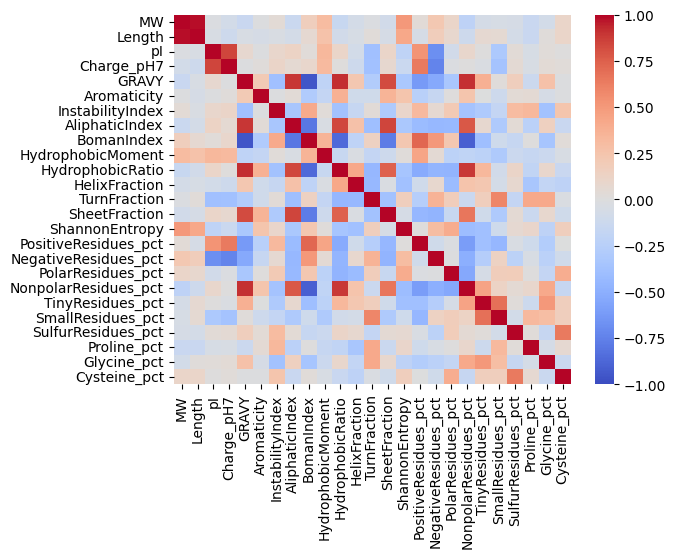

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

biophysical_params = biophysical_df.drop(columns=['Sequence', 'Class'])
corr_matrix = biophysical_params.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

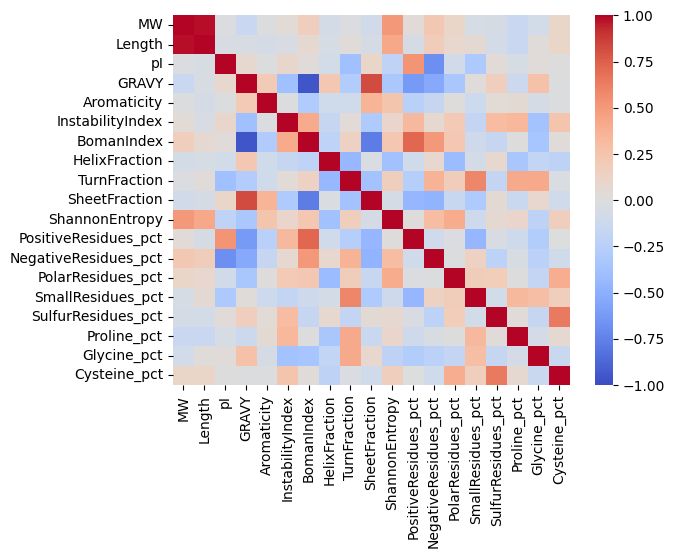

In [ ]:
features_to_drop = ['NonpolarResidues_pct', 'HydrophobicRatio', 'AliphaticIndex', 'HydrophobicMoment', 'Charge_pH7', 'TinyResidues_pct']

new_corr_matrix = biophysical_params.drop(columns=features_to_drop).corr()

sns.heatmap(new_corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [ ]:
columns_to_subset = ["Sequence", "Class"] + biophysical_params.drop(columns=features_to_drop).columns.tolist()
curated_params_df = biophysical_df[columns_to_subset]
curated_params_df

,Sequence,Class,MW,Length,pI,GRAVY,Aromaticity,InstabilityIndex,BomanIndex,HelixFraction,...,SheetFraction,ShannonEntropy,PositiveResidues_pct,NegativeResidues_pct,PolarResidues_pct,SmallResidues_pct,SulfurResidues_pct,Proline_pct,Glycine_pct,Cysteine_pct
0,MSQNVLTVYGADWCRDCLRTKRQLDELGVAYDYVDLVADPAQADAA...,AMP,9218.249,84,4.469,-0.2357,0.0595,36.588,1.751,0.3214,...,0.3571,4.0145,10.71,16.67,22.62,47.62,3.57,4.76,5.95,2.38
1,MAKAELRKPKPKSNPLKAAKITEIDYKDVALLRKFISDRGKIRARR...,AMP,8756.247,79,10.853,-0.5481,0.0380,23.335,2.320,0.4304,...,0.2911,3.7708,25.32,8.86,15.19,39.24,1.27,5.06,6.33,0.00
2,MAEKKTEKNGAPMGPGTSSIKDPEVYEALRREGASEEKAARIANAS...,AMP,10934.853,99,5.019,-1.1606,0.0303,43.276,3.389,0.4545,...,0.1919,3.7184,19.19,23.23,16.16,47.47,3.03,3.03,9.09,0.00
3,VNFALDGRNYEIDLSKEHAAELREFLKPYMKKGRAVAPPSPKVEAA...,AMP,9084.225,79,9.845,-0.8975,0.0886,28.275,2.809,0.4177,...,0.2532,3.8676,24.05,13.92,16.46,37.97,1.27,5.06,5.06,0.00
4,MTDVPFEDREDERELETDLLADPNAAGDPEPEDGRDGQPVRGGSDD...,AMP,9655.977,88,4.050,-1.2784,0.0227,65.364,3.564,0.3409,...,0.1705,3.6616,11.36,31.82,12.50,54.55,2.27,7.95,9.09,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,MPEQCPPSVSDQDQIPTLTDQQWTEFVSDAHAMRQAETTLEAGMAD...,NAMP,9387.308,83,4.366,-0.7289,0.0361,64.746,2.693,0.3253,...,0.2651,3.7715,9.64,16.87,30.12,44.58,6.02,6.02,2.41,1.20
152,MEFDPETNTYSSNGPTTRLRNAEQENRDLKRRLKDLEDRVDRLEEI...,NAMP,6051.499,50,4.587,-1.6120,0.0400,62.916,4.575,0.3800,...,0.2800,3.6579,18.00,28.00,26.00,38.00,2.00,4.00,2.00,0.00
153,MPVSPCPECGRPVIPAGIGQPPRFCSTSCRQRRHRKVKNVRQQLAE...,NAMP,8366.619,73,10.399,-0.7767,0.0685,78.329,2.837,0.2466,...,0.2466,3.9956,20.55,8.22,23.29,45.21,8.22,12.33,6.85,5.48
154,VKTRRAYTAAGMAAFLSELQRRHGAPAQTGTRVGVHPAPQETPPLT...,NAMP,6629.307,63,7.010,-0.6746,0.0317,60.657,1.980,0.3175,...,0.3016,3.5892,14.29,9.52,23.81,58.73,1.59,14.29,7.94,0.00


In [ ]:
folder_dir

'/content/drive/MyDrive/IIMT/'

In [ ]:
curated_params_df.loc[train_df.index].to_csv(folder_dir+'notebook-output/day-2/train-124-biophysical-curated.csv', index=False)

In [ ]:
curated_params_df.loc[test_df.index].to_csv(folder_dir+'notebook-output/day-2/test-32-biophysical-curated.csv', index=False)